# Evolvability landscape features

Illustrates MOLA's **evolvability** landscape features (paper §4.1.3, Table 1) — measures of the expected improvement reachable from a solution's neighbourhood. Each section pairs a feature's definition with a small, real, *executed* example built on `mola`'s own code.

Built incrementally — one section is added per feature, in the same commit that implements it (see `CLAUDE.md`'s "Feature implementation matrix"). As of this notebook: `sup_avg_neig`, `inf_avg_neig`, `inc_avg_neig`.

## `sup_avg_neig`, `inf_avg_neig`, `inc_avg_neig` — pairwise dominance with neighbours

> "the proportions of dominating (sup), dominated (inf), and incomparable (inc) neighbours" (§4.1.3)

For each solution, `mola.dominance.neighbourhood_dominance` tests genuine **pairwise** dominance (jMetalPy's `DominanceComparator.dominance_test`) against each of its neighbours individually. This is deliberately *not* a comparison of global non-dominated ranks: while building this module, reading MOORPHOLOGY's source directly showed its equivalent computation compares each neighbour's *global* rank against the reference solution's — not equivalent to pairwise dominance, since two solutions can sit in different global fronts without either directly dominating the other (front assignment reflects the whole sample's structure, not just the pair). `CLAUDE.md`'s Audit section records the correction.

Each proportion is divided by the neighbourhood's *actual* size, and the three always sum to 1 per solution — every neighbour comparison falls into exactly one bucket.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from mola.distance import build_neighbourhood
from mola.dominance import neighbourhood_dominance
from mola.features import inc_avg_neig, inf_avg_neig, sup_avg_neig

# A toy bi-objective problem: two sphere functions centred at (1, 1) and (-1, -1), so
# variable-space location has real, interpretable structure in objective space -- not
# an arbitrary unrelated pair of arrays.
toy_rng = np.random.default_rng(seed=2)
variables = toy_rng.uniform(low=-2.0, high=2.0, size=(10, 2))
objectives = np.column_stack(
    [
        ((variables - 1.0) ** 2).sum(axis=1),
        ((variables + 1.0) ** 2).sum(axis=1),
    ]
)

# k = D, per Design decisions ("Neighbourhood definition")
neighbourhood = build_neighbourhood(variables, neighbours=variables.shape[1])
dominance = neighbourhood_dominance(objectives, neighbourhood)

sup, inf, inc = (
    sup_avg_neig(dominance, neighbourhood),
    inf_avg_neig(dominance, neighbourhood),
    inc_avg_neig(dominance, neighbourhood),
)
print(f"sup_avg_neig = {sup:.3f}")
print(f"inf_avg_neig = {inf:.3f}")
print(f"inc_avg_neig = {inc:.3f}")
print(f"sum = {sup + inf + inc:.3f}")

sup_avg_neig = 0.250
inf_avg_neig = 0.150
inc_avg_neig = 0.600
sum = 1.000


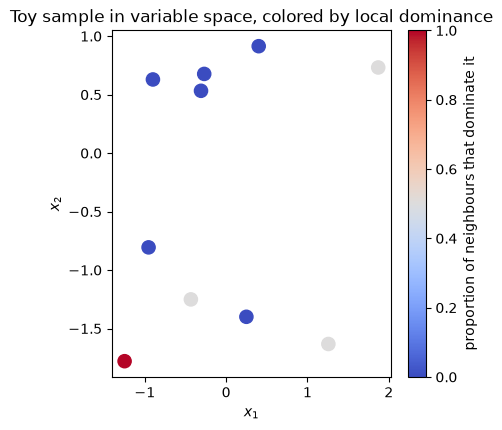

In [2]:
fig, ax = plt.subplots(figsize=(4.5, 4.5))
sup_per_solution = dominance.dominating / neighbourhood.size
scatter = ax.scatter(variables[:, 0], variables[:, 1], c=sup_per_solution, cmap="coolwarm", s=90)
fig.colorbar(scatter, ax=ax, label="proportion of neighbours that dominate it")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_title("Toy sample in variable space, colored by local dominance")
plt.show()

## `dist_x_avg_neig`, `dist_f_avg_neig`, `dist_f_dist_x_avg_neig` — distance to neighbours

> "the average distance from each solution to its neighbours in the variable space and in the objective space" (§4.1.3)

Reuses the same toy sample and `neighbourhood` from the section above. The ratio `dist_f_dist_x_avg_neig` (Table 1's own parenthetical formula) is a rough local sensitivity signal: large means small variable-space steps among neighbours translate into large objective-space jumps (a rugged, sensitive area); small means the opposite (a locally flat, redundant area).

In [3]:
from mola.features import dist_f_avg_neig, dist_f_dist_x_avg_neig, dist_x_avg_neig

print(f"dist_x_avg_neig        = {dist_x_avg_neig(variables, neighbourhood):.3f}")
print(f"dist_f_avg_neig        = {dist_f_avg_neig(objectives, neighbourhood):.3f}")
print(
    f"dist_f_dist_x_avg_neig = {dist_f_dist_x_avg_neig(objectives, variables, neighbourhood):.3f}"
)

dist_x_avg_neig        = 0.874
dist_f_avg_neig        = 3.110
dist_f_dist_x_avg_neig = 3.560


## `diff_f_avg_neig`, `diff_f_dist_x_avg_neig` — per-objective difference with neighbours

> "the average difference **per objective** with neighbours" (§4.1.3)

Distinct from `dist_f_avg_neig` above: this is the mean *absolute* per-objective difference (an L1-flavoured measure), not Euclidean distance (L2). `diff_f_dist_x_avg_neig` is the same ratio idea as `dist_f_dist_x_avg_neig`, with `diff_f_avg_neig` in place of `dist_f_avg_neig`.

In [4]:
from mola.features import diff_f_avg_neig, diff_f_dist_x_avg_neig

print(f"diff_f_avg_neig        = {diff_f_avg_neig(objectives, neighbourhood):.3f}")
print(
    f"diff_f_dist_x_avg_neig = {diff_f_dist_x_avg_neig(objectives, variables, neighbourhood):.3f}"
)

diff_f_avg_neig        = 1.787
diff_f_dist_x_avg_neig = 2.045


## `hv_avg_neig`, `hvd_avg_neig` — hypervolume with neighbours

> "average **(single)** solution's hypervolume" / "...hypervolume difference with neighbours" (§4.1.3)

`hv_avg_neig` scores each solution in isolation against one reference point shared by every hypervolume-based feature (the whole sample's per-objective maximum, no padding) — deliberately **not** `moocore.hv_contributions`, which measures marginal value relative to the rest of the set rather than a per-solution signal (Design decisions). `hvd_avg_neig` reuses that same per-solution array: the mean `|hv(i) - hv(j)|` with each solution's own neighbours.

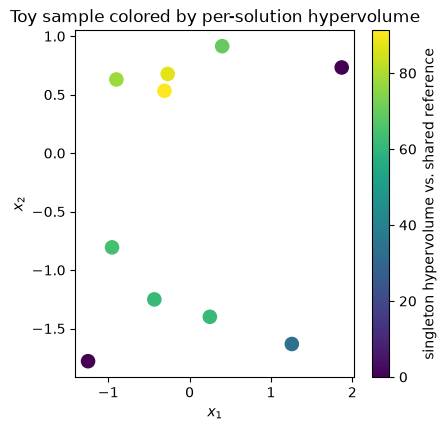

hv_avg_neig  = 54.552
hvd_avg_neig = 26.508


In [5]:
from mola.features import hv_avg_neig, hvd_avg_neig
from mola.hypervolume import reference_point, singleton_hypervolume

ref = reference_point(objectives)
hv_per_solution = singleton_hypervolume(objectives, ref)

fig, ax = plt.subplots(figsize=(4.5, 4.5))
scatter = ax.scatter(variables[:, 0], variables[:, 1], c=hv_per_solution, cmap="viridis", s=90)
fig.colorbar(scatter, ax=ax, label="singleton hypervolume vs. shared reference")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_title("Toy sample colored by per-solution hypervolume")
plt.show()

print(f"hv_avg_neig  = {hv_avg_neig(objectives, ref):.3f}")
print(f"hvd_avg_neig = {hvd_avg_neig(objectives, neighbourhood, ref):.3f}")